In [ ]:
import os
from typing import Any, List
import pdfplumber
import polars as pl
from pydantic import BaseModel, field_validator
from src.utils.converter import format_luas, format_number, format_text
from IPython.display import display

In [ ]:
current_path = os.getcwd()
script_dir = os.path.dirname(current_path)
input_dir = os.path.join(script_dir, "datas")
print(current_path)
print(input_dir)

In [ ]:
file_name = "Keputusan_Menteri_Dalam_Negeri_Nomor_300.2.2-2138_Tahun_2025.pdf"
pdf_path = os.path.join(input_dir, file_name)

In [ ]:
kecamatan_index_settings = {
    # "vertical_strategy": "lines",
    # "horizontal_strategy": "lines",
    # "snap_y_tolerance": 7,
    # "intersection_y_tolerance": 500,
    # "intersection_x_tolerance": 500,
}

In [ ]:
start_page_index = 20
end_page_index = 30
# start_page_index = 1332
# end_page_index = 1333

page_numbers = list(range(start_page_index, end_page_index + 1))
print(page_numbers)


Processing page 2:


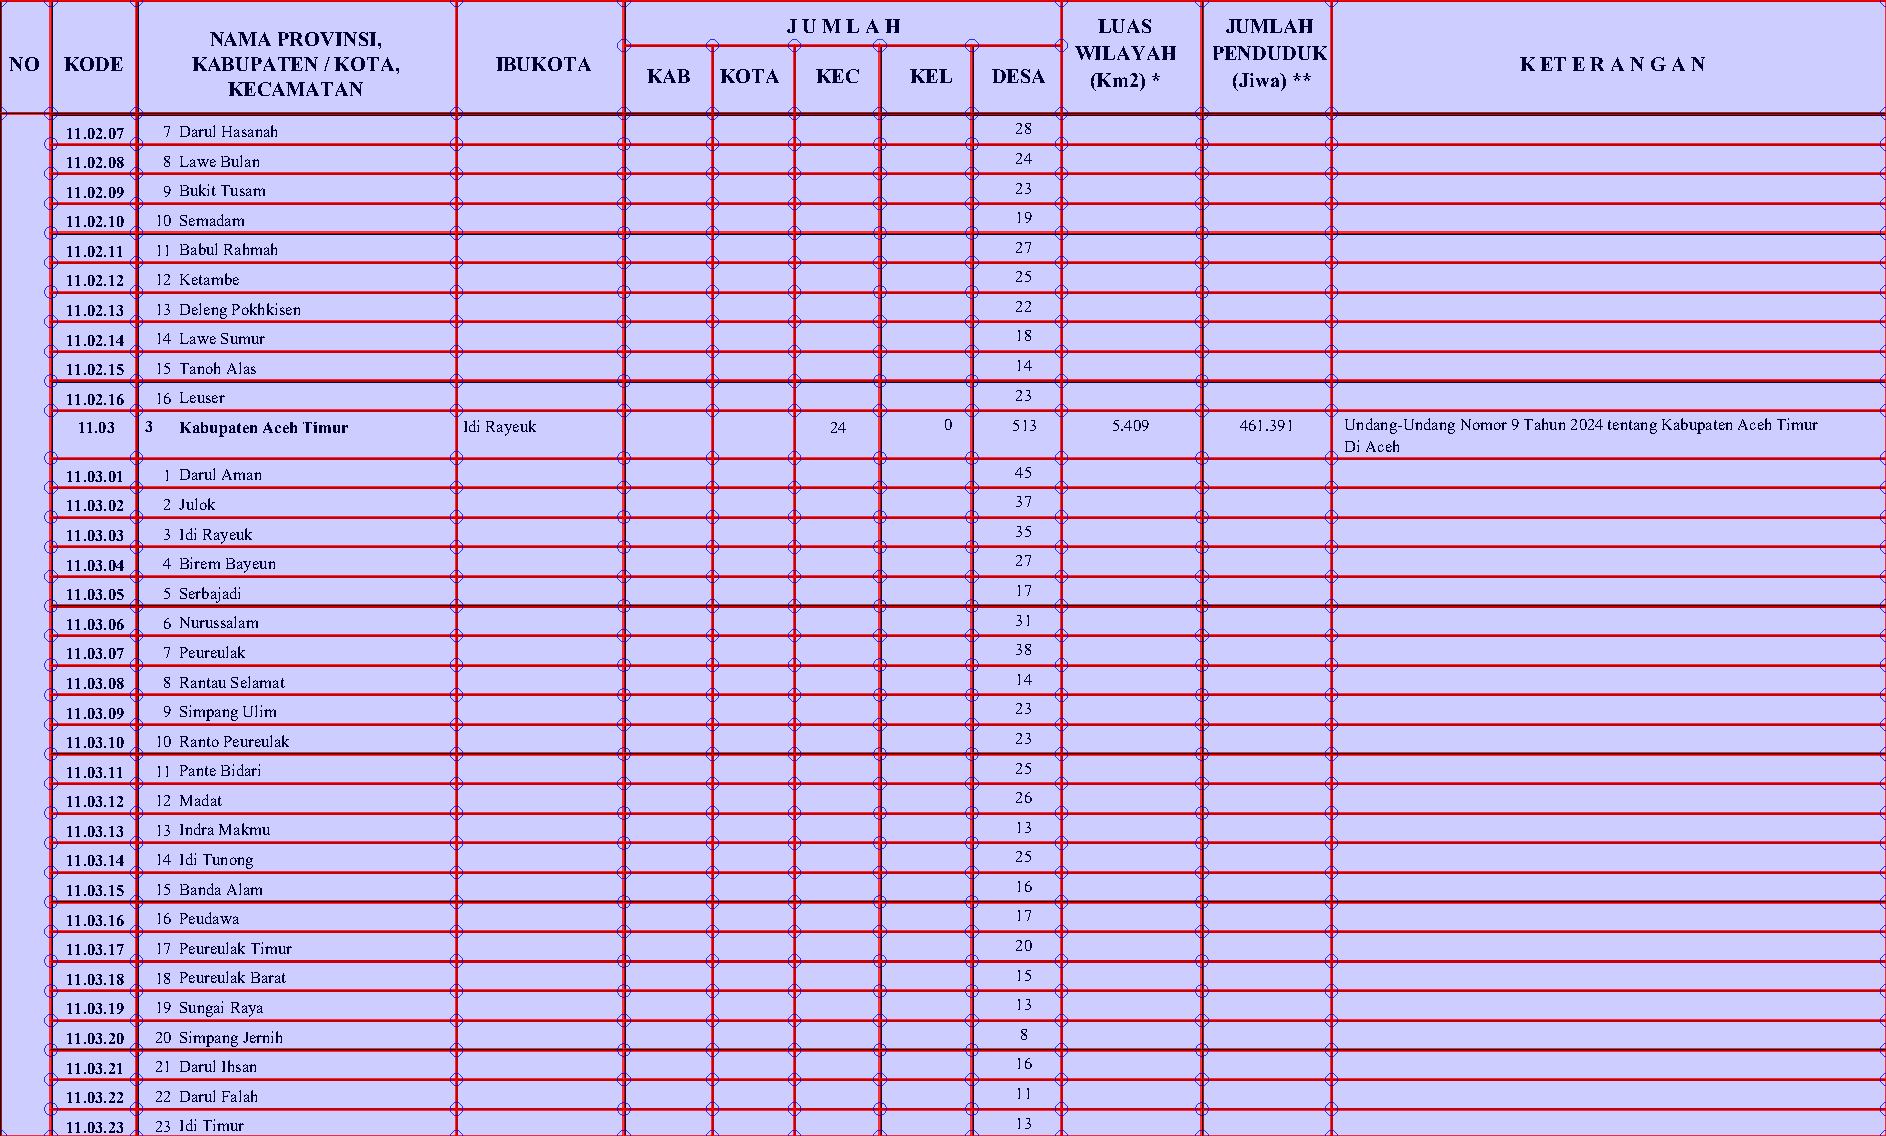


Processing page 3:


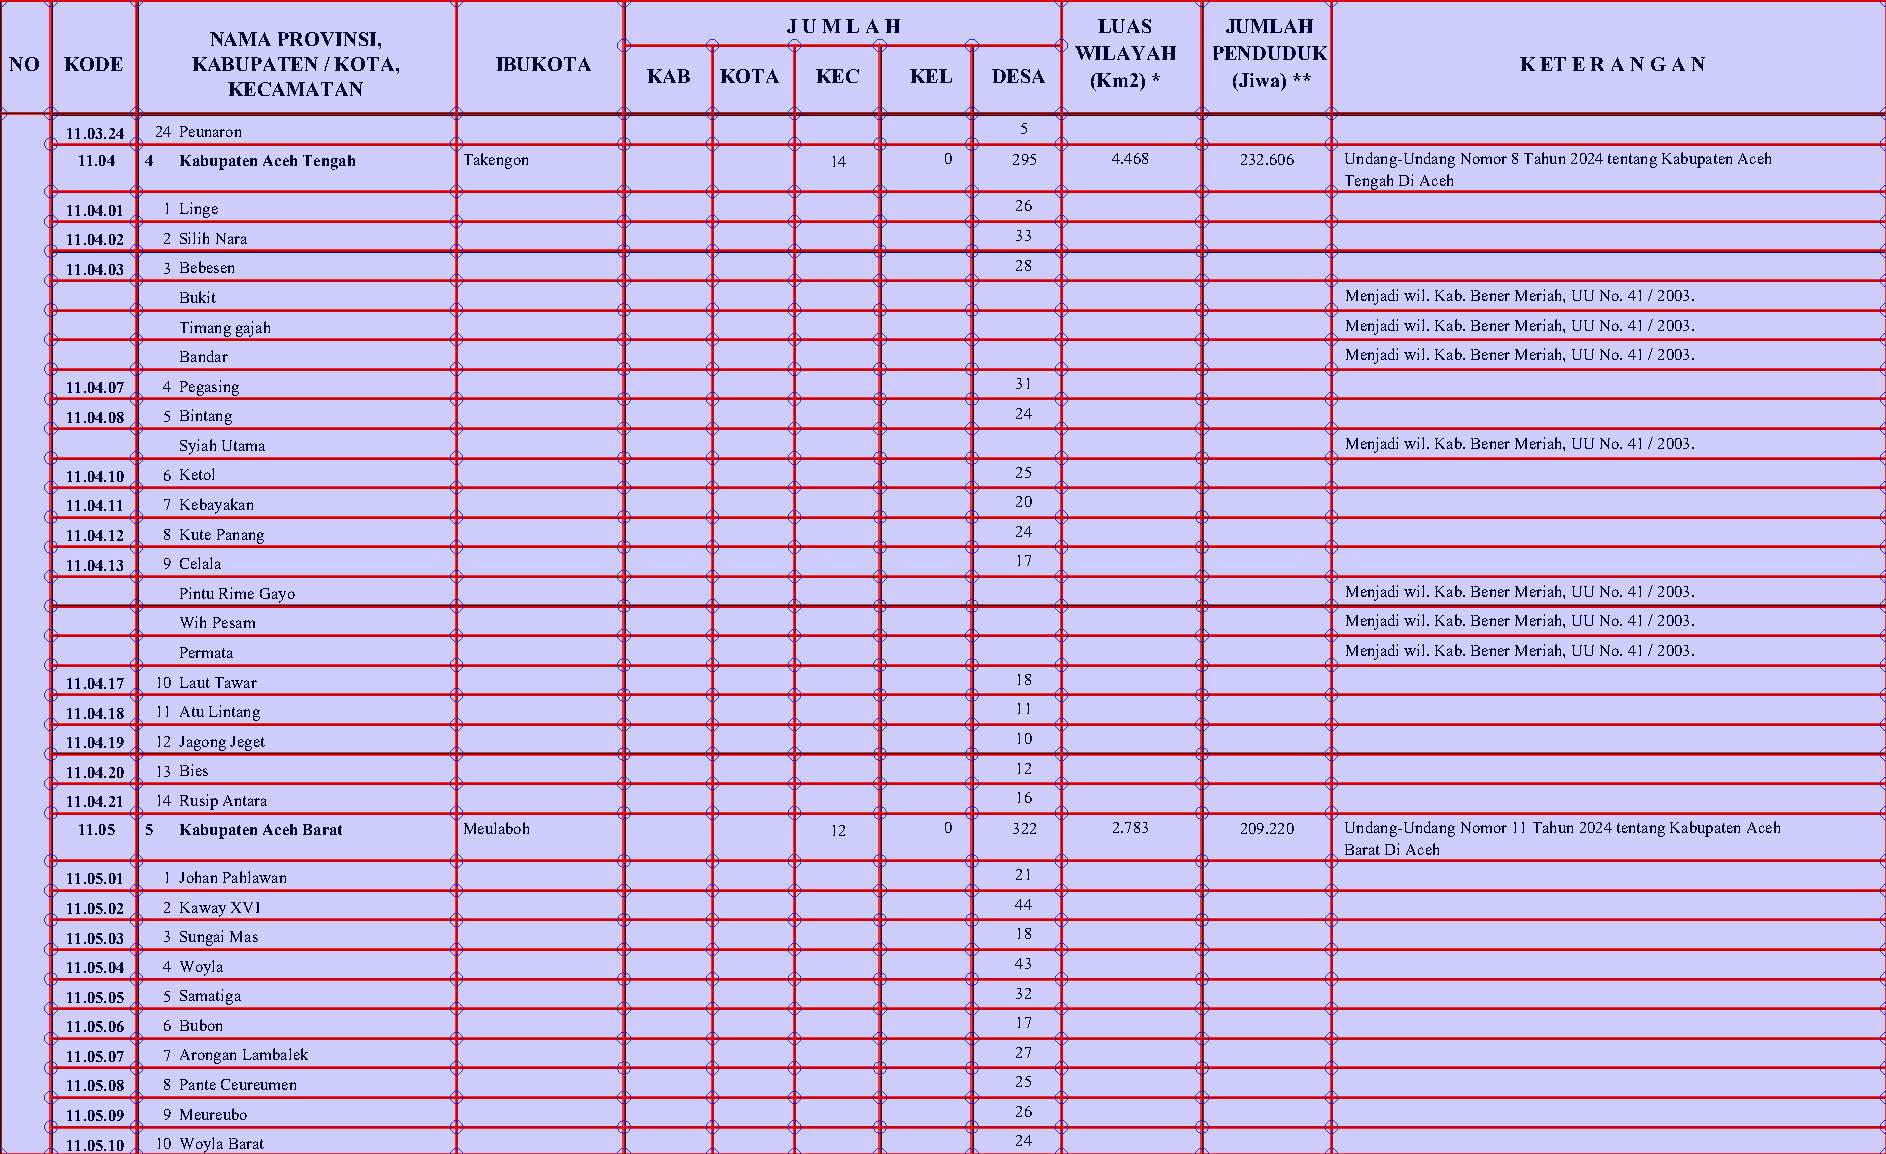


Processing page 4:


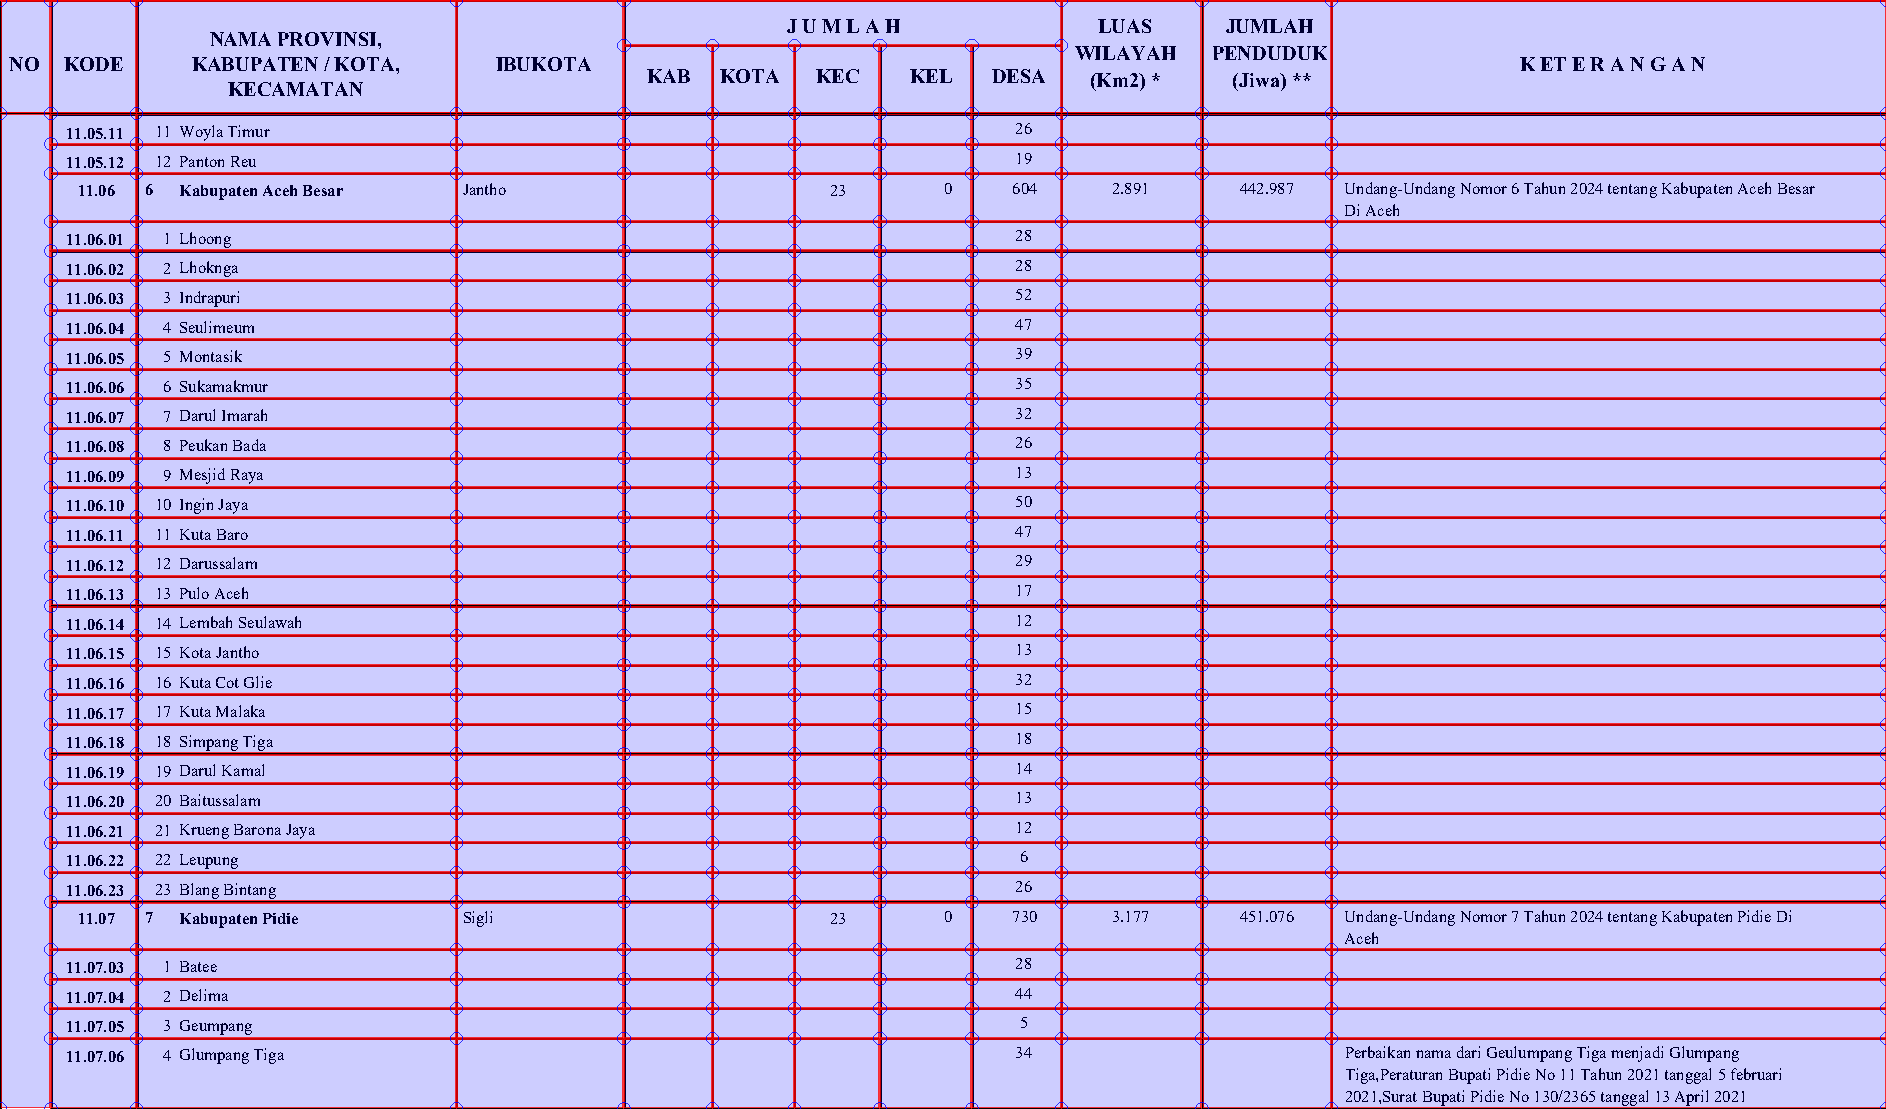


Processing page 5:


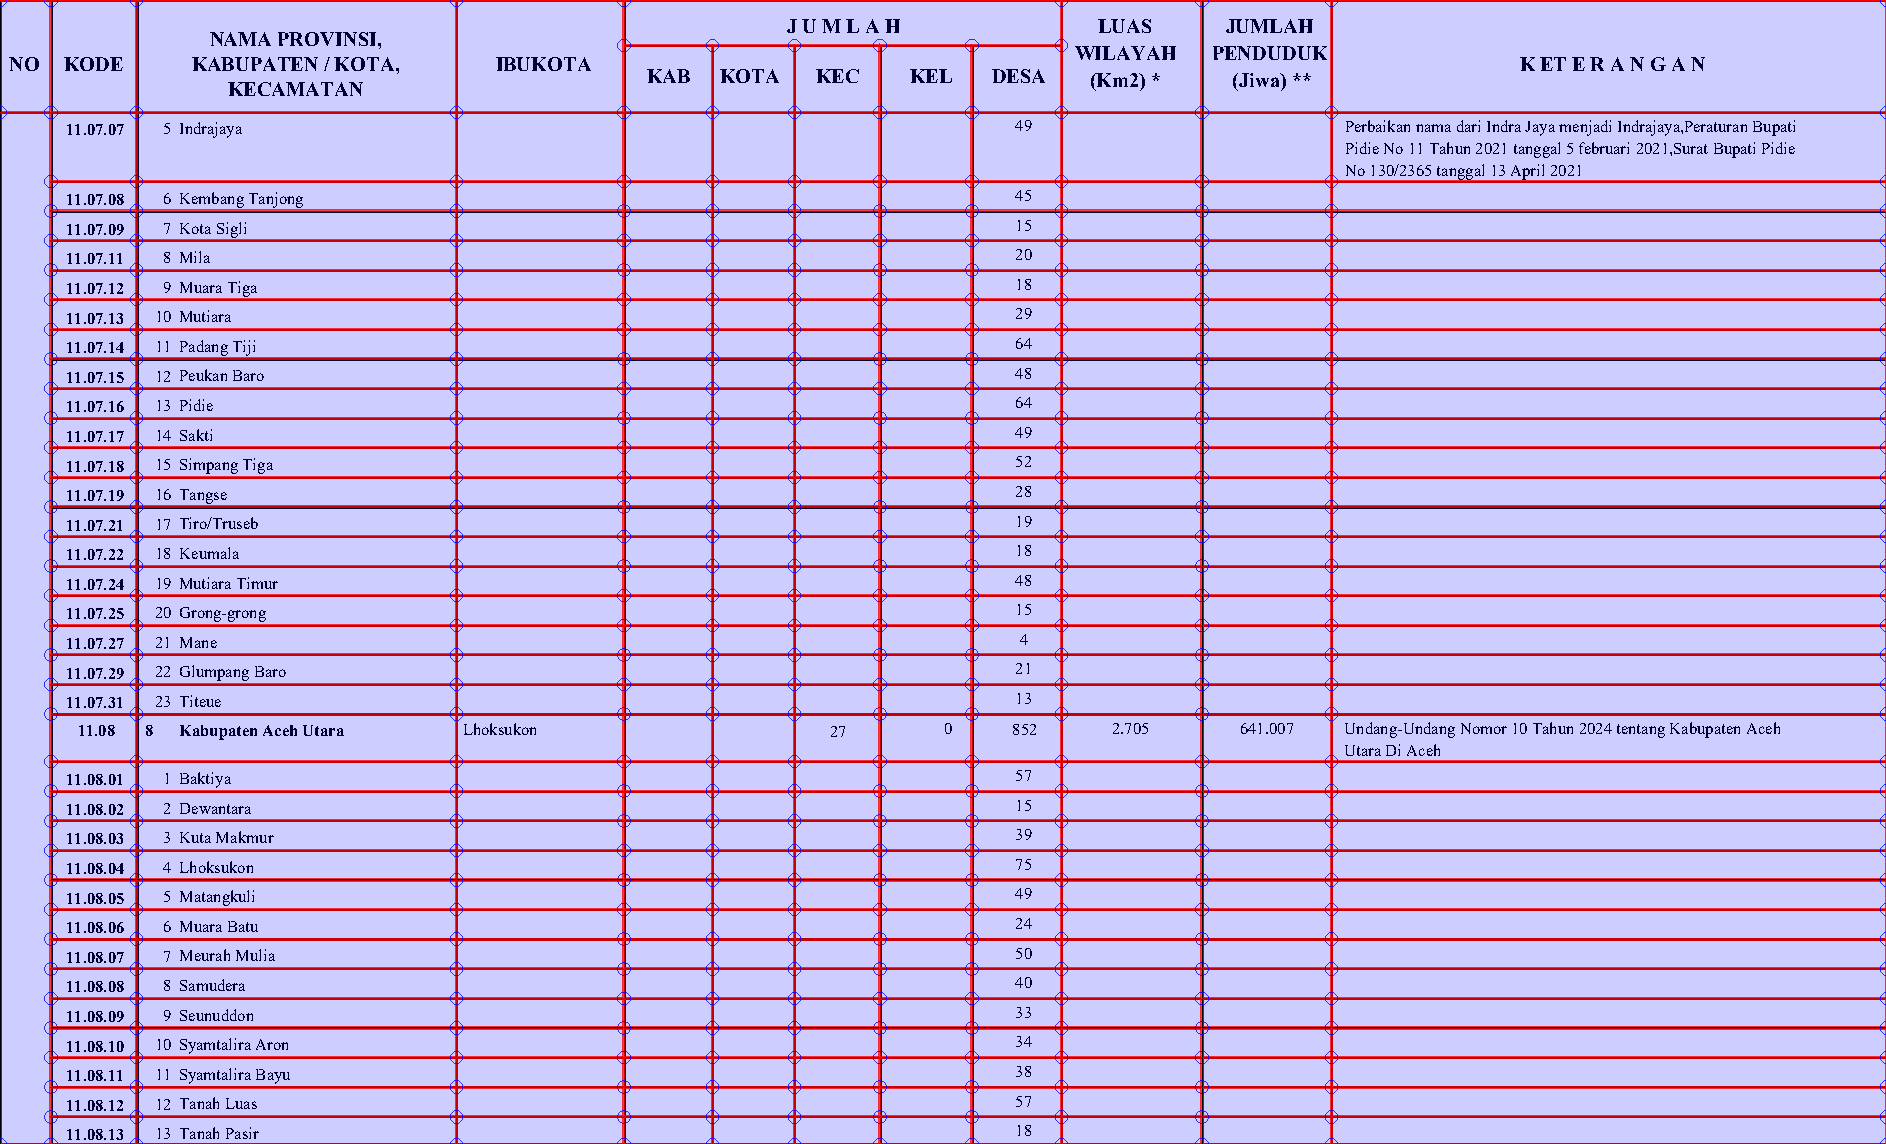


Processing page 6:


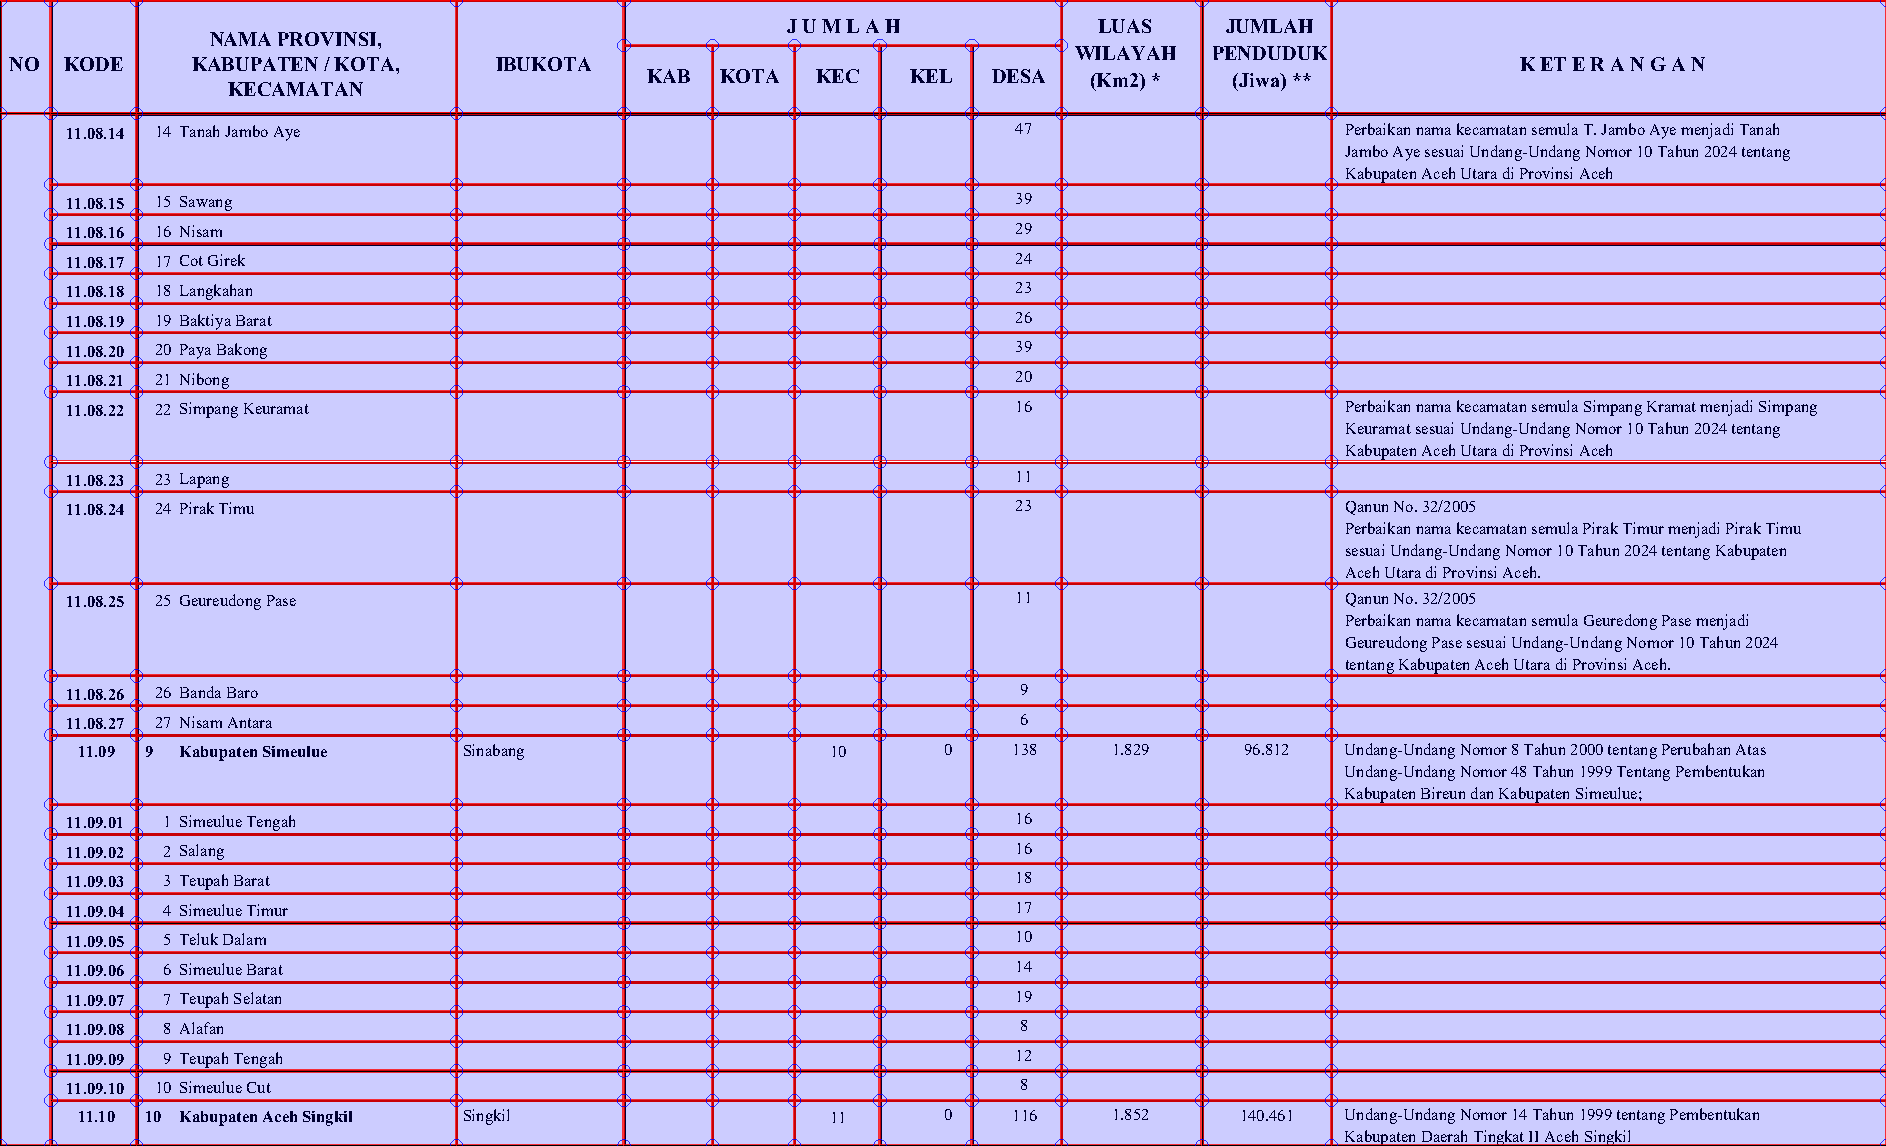


Processing page 7:


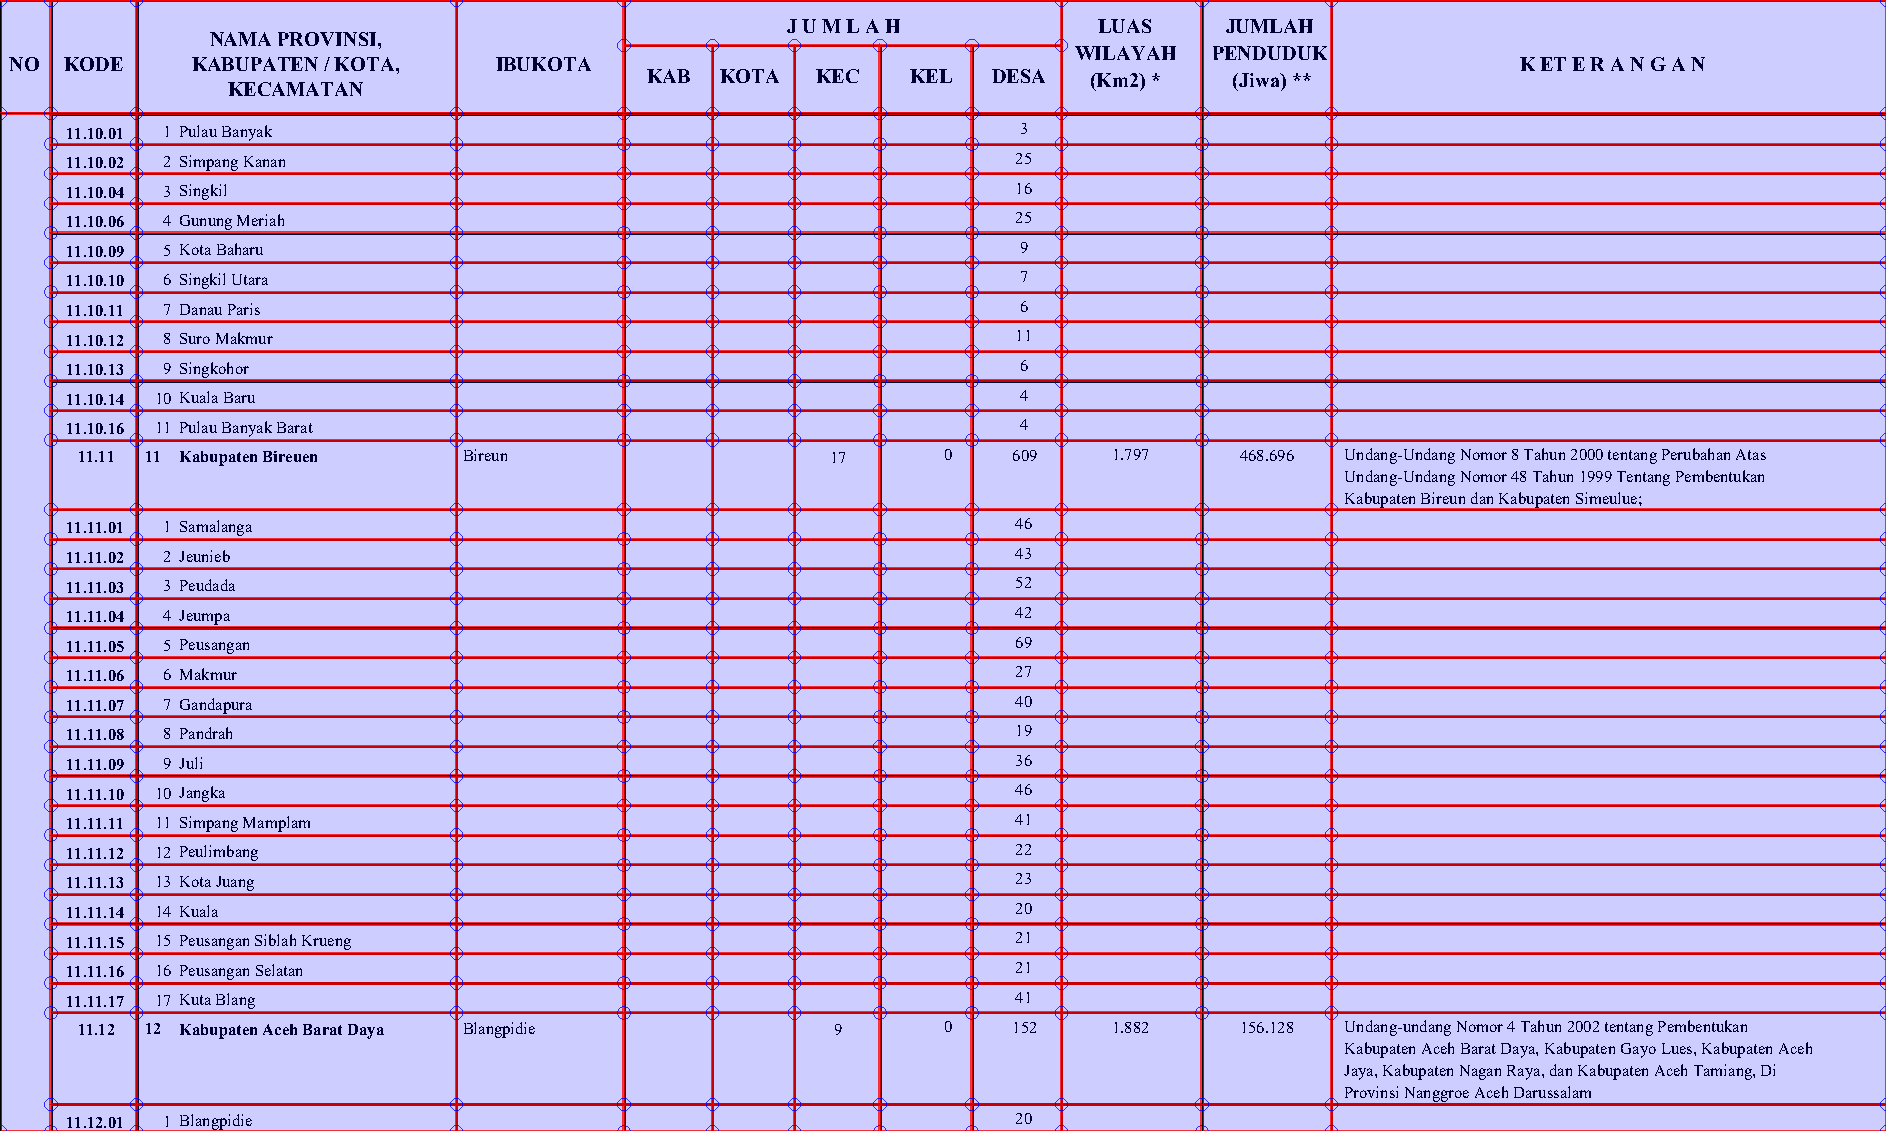


Processing page 8:


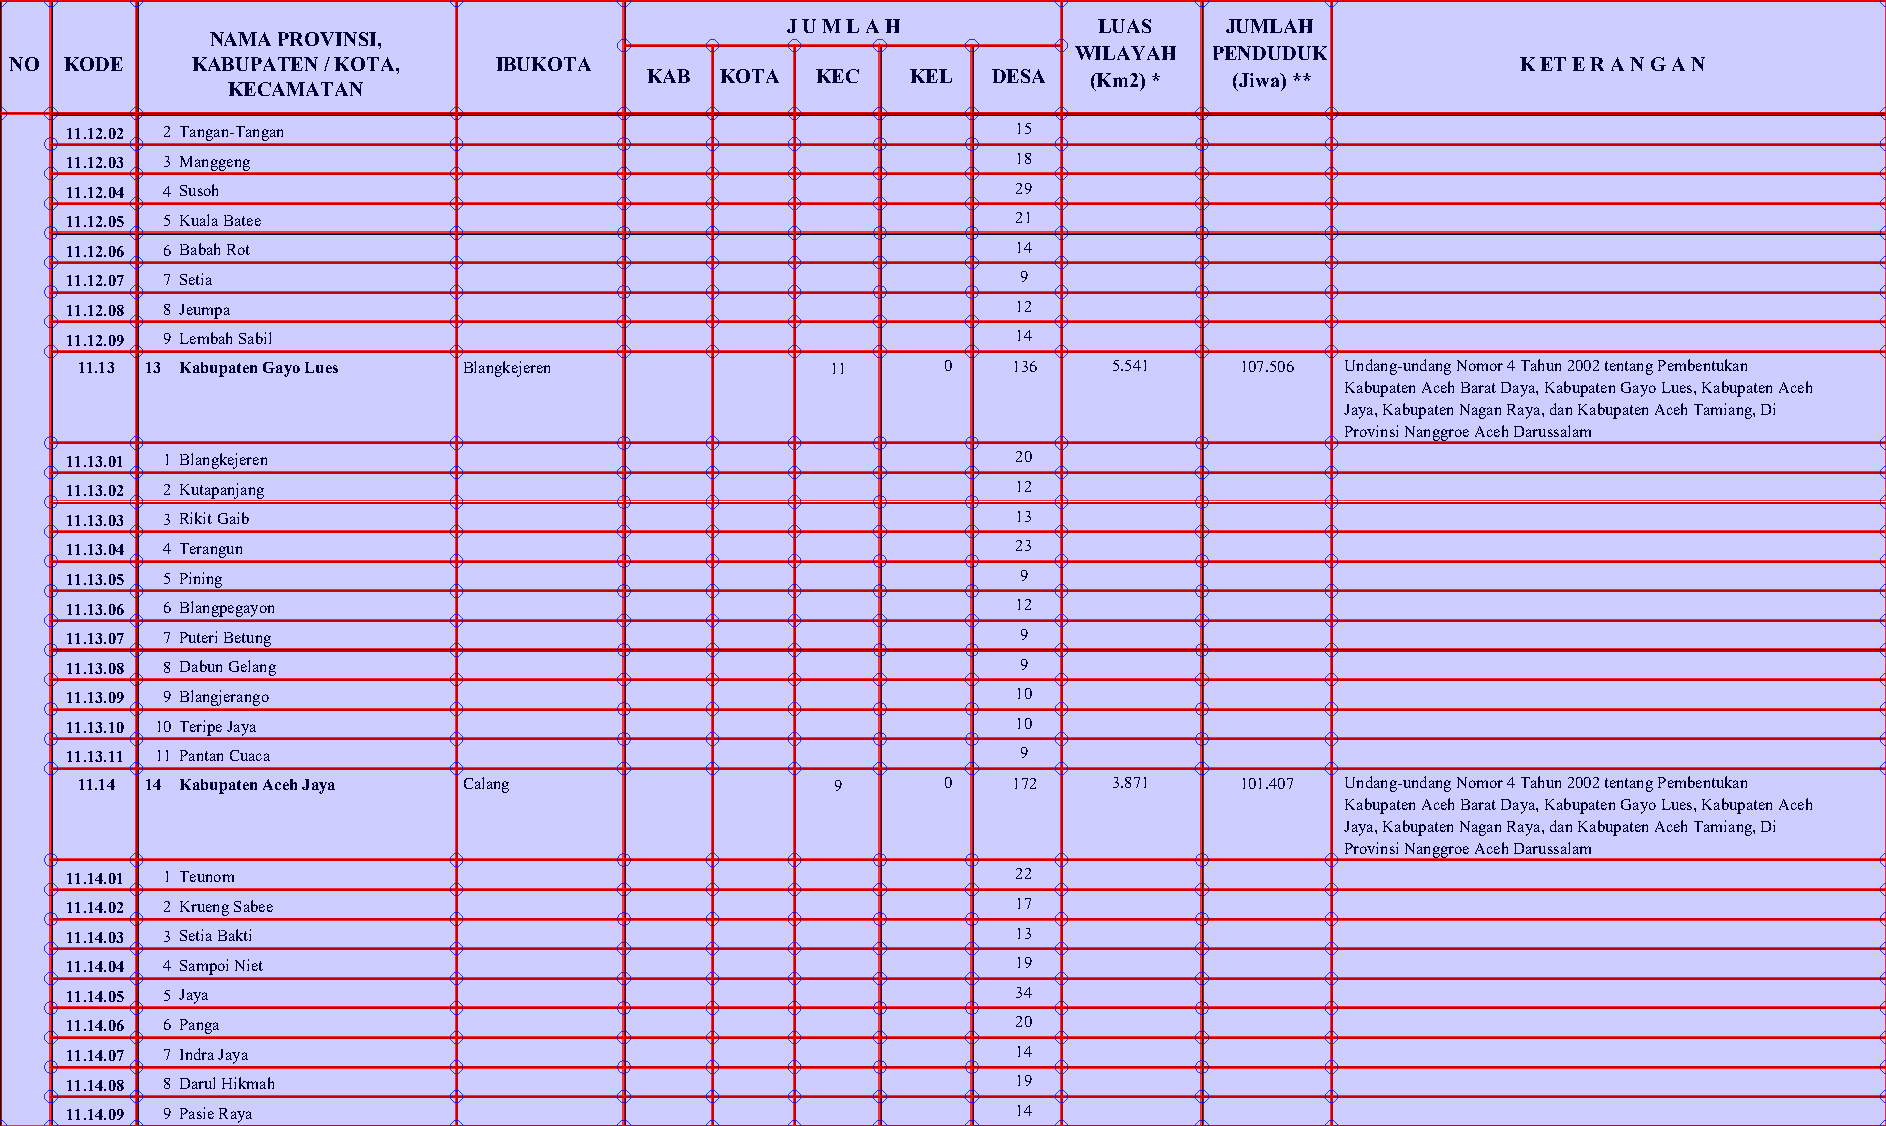


Processing page 9:


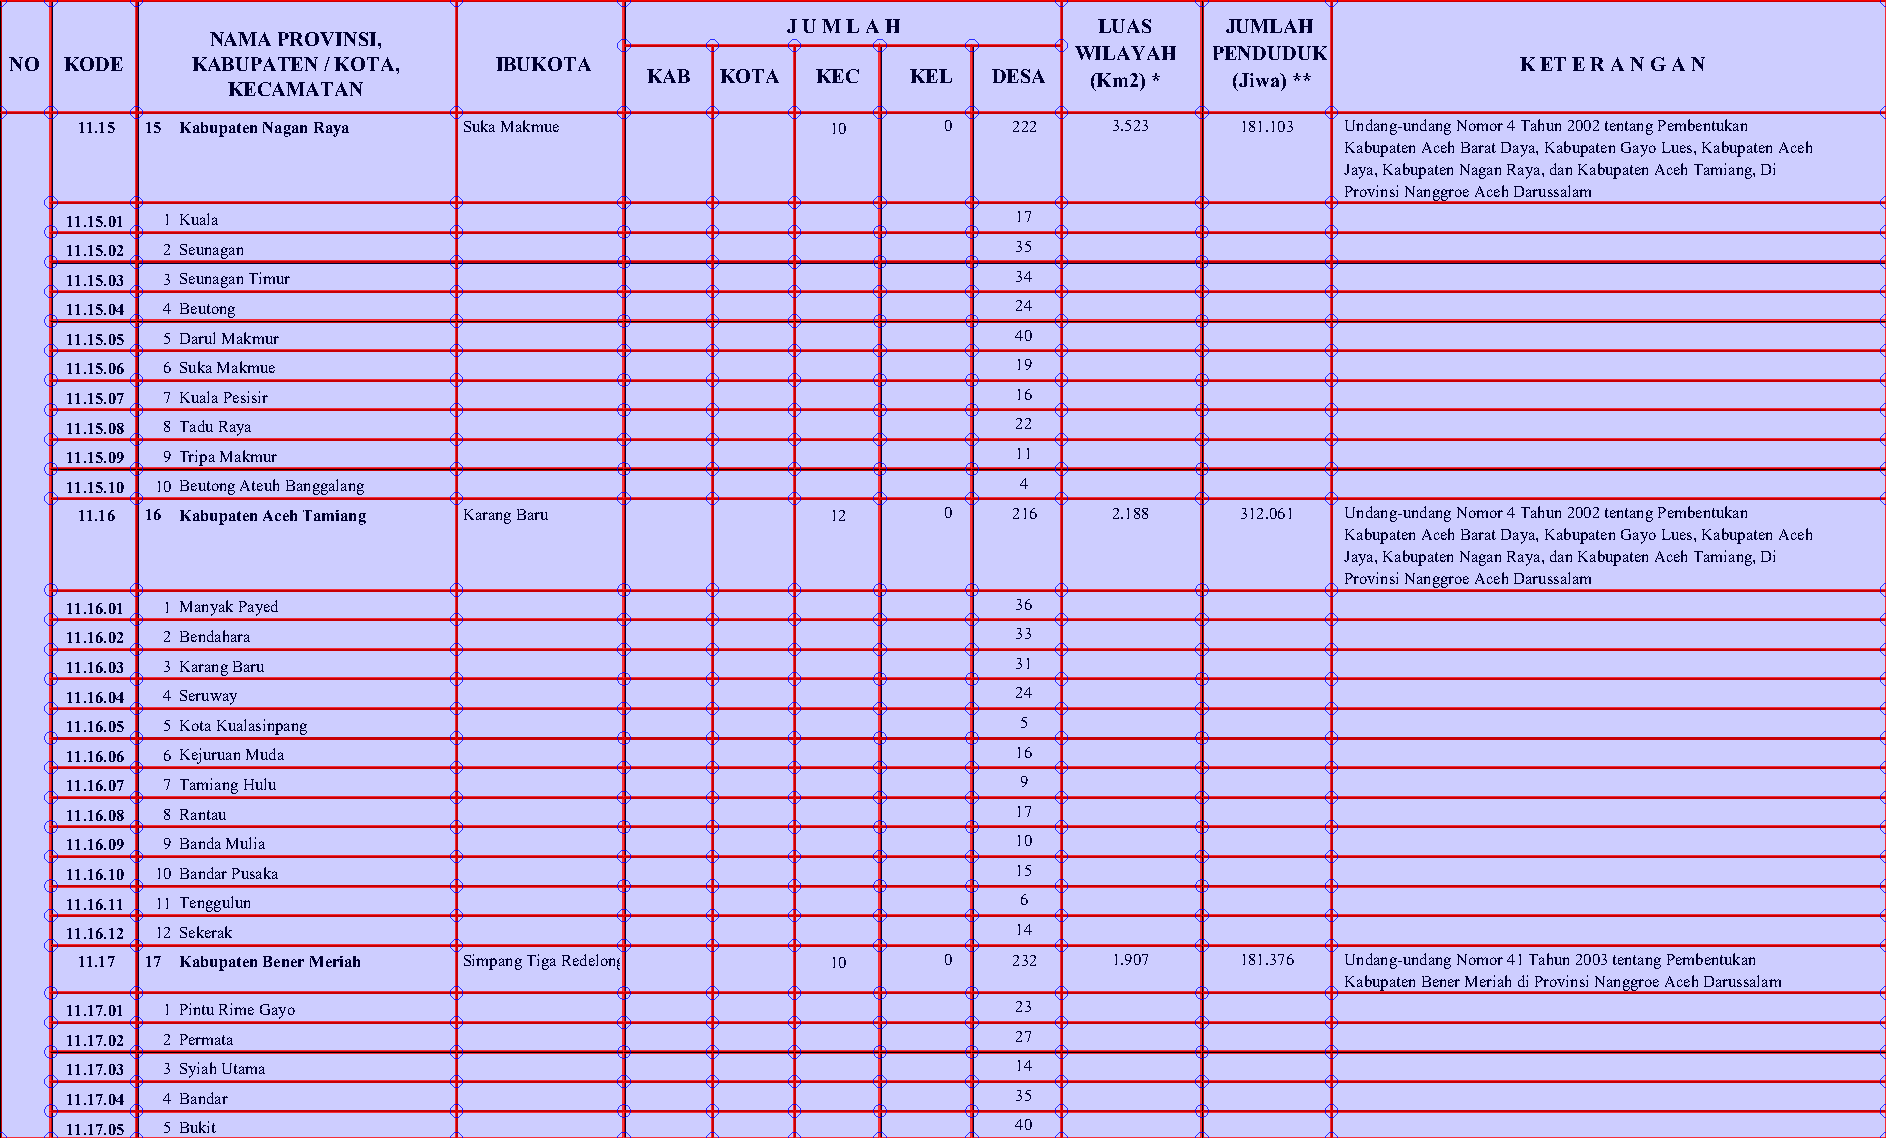


Processing page 10:


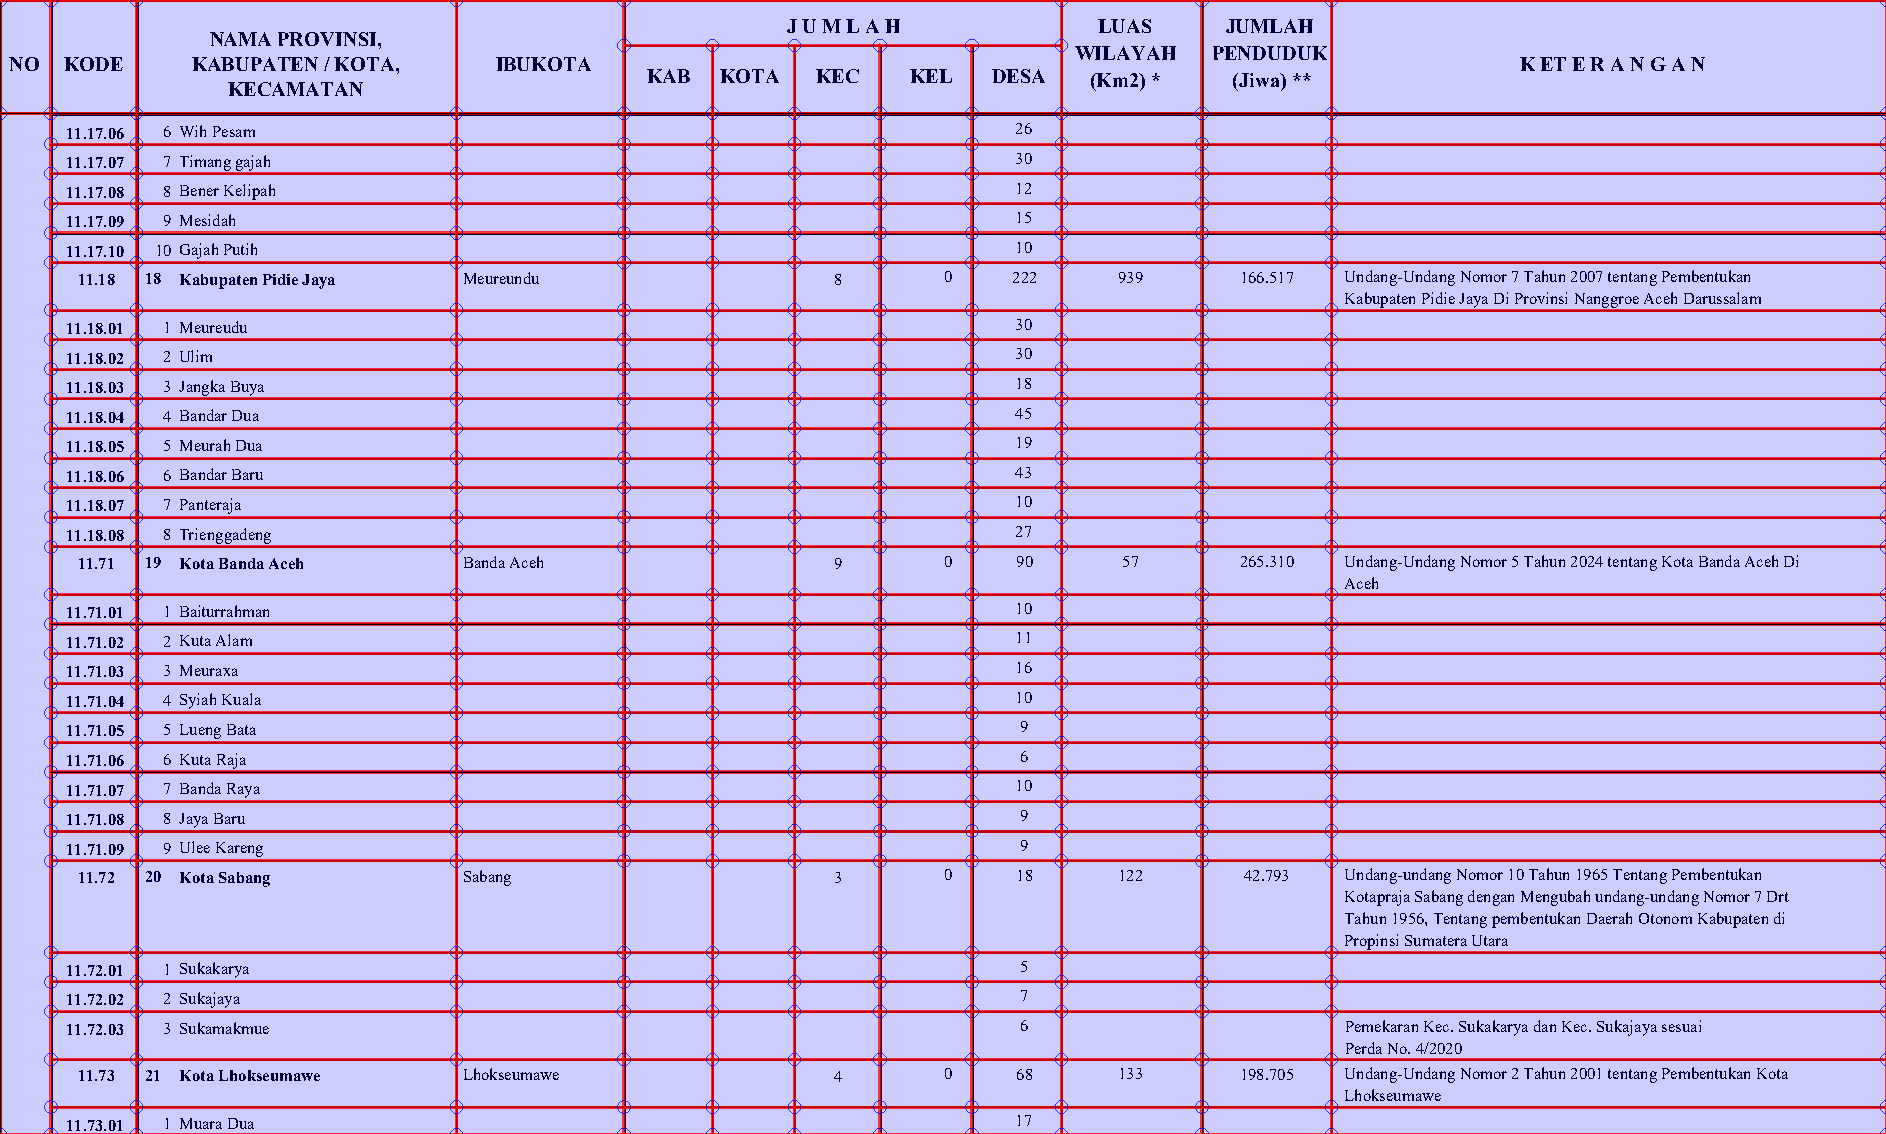


Processing page 11:


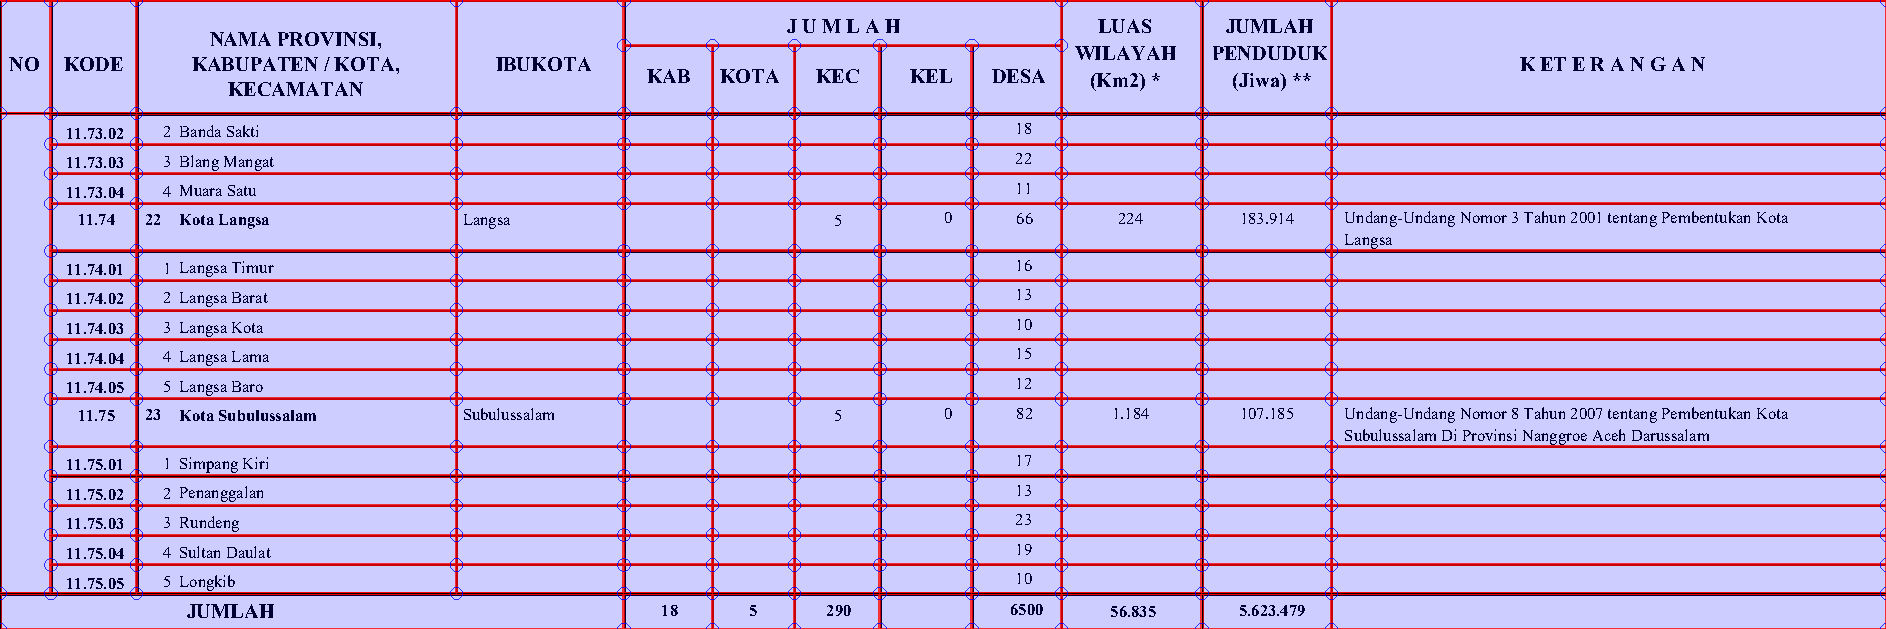

In [31]:
with pdfplumber.open(pdf_path, pages=page_numbers) as pdf:
    if pdf.pages:
        for i, page in enumerate(pdf.pages):
            print(f"\nProcessing page {i + 1}:")
            table = page.find_table()
            if table is not None and table.bbox is not None:
                table_bbox = table.bbox
                the_table = page.crop(table_bbox)
                im = the_table.to_image(resolution=150)
                table_extract = im.debug_tablefinder(kecamatan_index_settings)
                value_table = the_table.extract_table(kecamatan_index_settings)
                display(table_extract)
                replacement_value = ""

In [32]:
raw_records = []

with pdfplumber.open(pdf_path, pages=page_numbers) as pdf:
    if pdf.pages:

        for i, page in enumerate(pdf.pages):
            table = page.extract_table(kecamatan_index_settings)
            if table is not None:
                for row in table:
                    if any(row) :
                        raw_records.append(row)

In [33]:
def are_sublist_lengths_same(main_list):
    if not main_list:
        return True

    lengths = {len(sublist) for sublist in main_list}
    if len(lengths) == 1:
        return "Ok"
    else:
        raise ValueError("Not same length")


In [34]:
print(are_sublist_lengths_same(raw_records))
print(len(raw_records[0]))

Ok
12


In [35]:
raw_records

[['NO',
  'KODE',
  'NAMA PROVINSI,\nKABUPATEN / KOTA,\nKECAMATAN',
  'IBUKOTA',
  'J U M L A H',
  None,
  None,
  None,
  None,
  'LUAS\nWILAYAH\n(Km2) *',
  'JUMLAH\nPENDUDUK\n(Jiwa) **',
  'K ET E R A N G A N'],
 [None,
  None,
  None,
  None,
  'KAB',
  'KOTA',
  'KEC',
  'KEL',
  'DESA',
  None,
  None,
  None],
 ['I',
  '11',
  'Aceh',
  'Banda Aceh',
  '18',
  '5',
  '290',
  '',
  '6500',
  '56.835',
  '5.623.479',
  'Undang-undang Nomor 11 Tahun 2006 tentang Pemerintahan Aceh'],
 [None,
  '11.01',
  '1 Kabupaten Aceh Selatan',
  'Tapaktuan',
  '',
  '',
  '18',
  '0',
  '260',
  '4.174',
  '239.629',
  'Perbaikan nama ibu kota semula Tapak Tuan menjadi Tapaktuan\nsesuai Undang-Undang Nomor 12 Tahun 2024 tentang Kabupaten\nAceh Selatan di Aceh.'],
 [None, '11.01.01', '1 Bakongan', '', '', '', '', '', '7', '', '', ''],
 [None, '11.01.02', '2 Kluet Utara', '', '', '', '', '', '21', '', '', ''],
 [None, '11.01.03', '3 Kluet Selatan', '', '', '', '', '', '17', '', '', ''],
 [None,

In [36]:
class RegencyIndexData(BaseModel):
    no: int
    kode: str
    kabupaten_kota: str
    jumlah_kecamatan: int
    jumlah_kelurahan: int
    jumlah_desa: int
    luas_wilayah_km2: float
    jumlah_penduduk: int
    keterangan: str

    @field_validator(
        "no",
        "jumlah_kecamatan",
        "jumlah_kelurahan",
        "jumlah_desa",
        "jumlah_penduduk",
        mode="before",
    )
    @classmethod
    def validate_int_fields(cls, v):
        if v is None or v == "":
            return 0
        return int(format_number(v))

    @field_validator("luas_wilayah_km2", mode="before")
    @classmethod
    def validate_float_fields(cls, v):
        if v is None or v == "":
            return 0.0
        return float(format_luas(v))

    @field_validator("kode", "keterangan", mode="before")
    @classmethod
    def validate_str_fields(cls, v):
        """Normalize string fields to clean newlines and extra whitespace."""
        return format_text(v)

    @field_validator("kabupaten_kota", mode="before")
    @classmethod
    def validate_kabupaten_kota_field(cls, v):
        """Normalize kabupaten_kota field by expanding abbreviations."""
        from utils.converter import normalize_kabupaten_kota
        return normalize_kabupaten_kota(v)

In [37]:
clean_records = []

# Context variables for hierarchical data
current_province = {
    'no': '',  # Province Roman numeral
    'kode_provinsi': '',
    'provinsi': '',
    'ibukota_provinsi': '',
    'jumlah_kabupaten': 0,
    'jumlah_kota': 0
}
current_regency = {
    'kabupaten': '',
    'ibukota_kabupaten_kota': '',
    'jumlah_kecamatan': 0,
    'jumlah_kelurahan': 0,
    'jumlah_desa': 0
}

# Helper for safe row access (avoid shadowing)
def safe_row_val(row_data: List[Any], idx: int, default: Any = "") -> Any:
    return row_data[idx] if len(row_data) > idx and row_data[idx] is not None else default

for row in raw_records:
    if not row or len(row) < 10:
        continue

    first_cell = safe_row_val(row, 0, "").strip()
    kode = safe_row_val(row, 1, "").strip()

    # CHECK FOR HISTORICAL DISTRICTS FIRST - BEFORE header skip!
    district_name = safe_row_val(row, 2, "").strip()
    if (kode == "" and first_cell == "" and district_name and
        not district_name.isdigit() and district_name not in ['KAB', 'KOTA', 'KEC']):
        # Only process real historical districts with meaningful names
        keterangan_text = safe_row_val(row, 11, "")

        data = RegencyIndexData(
            no=current_province['no'],  # Inherit province Roman numeral
            kode_provinsi=current_province['kode_provinsi'],
            provinsi=current_province['provinsi'],
            ibukota_provinsi=current_province['ibukota_provinsi'],
            kode_kabupaten_kota="",
            kabupaten_kota="",
            ibukota_kabupaten_kota="",
            kode_kecamatan="",
            kecamatan=district_name,
            jumlah_kabupaten=0,
            jumlah_kota=0,
            jumlah_kecamatan=0,
            jumlah_kelurahan=0,
            jumlah_desa=0,
            luas_wilayah_km2=0.0,
            jumlah_penduduk=0,
            keterangan=keterangan_text
        )
        clean_records.append(data)
        continue

    # Skip headers - AFTER checking for historical districts
    if (first_cell == 'NO' or (first_cell == '' and kode == '') or
        (safe_row_val(row, 4) == 'KAB' and safe_row_val(row, 5) == 'KOTA')):
        continue

    # Parse codes
    kode_parts = kode.split('.') if kode else []
    if len(kode_parts) < 1:
        continue

    kode_provinsi = kode_parts[0]
    kode_kabupaten_kota = f"{kode_parts[0]}.{kode_parts[1]}" if len(kode_parts) > 1 else ""
    kode_kecamatan = kode if len(kode_parts) == 3 else ""

    if len(kode_parts) == 1:  # Province
        # Update context FIRST
        current_province.update({
            'no': first_cell,  # Store Roman numeral for inheritance
            'kode_provinsi': kode_provinsi,
            'provinsi': safe_row_val(row, 2, ""),
            'ibukota_provinsi': safe_row_val(row, 3, ""),
            'jumlah_kabupaten': safe_row_val(row, 4, 0),
            'jumlah_kota': safe_row_val(row, 5, 0)
        })

        # Use current row values directly for province data (not empty context)
        data = RegencyIndexData(
            no=first_cell,
            kode_provinsi=kode_provinsi,
            provinsi=safe_row_val(row, 2, ""),  # Direct from row
            ibukota_provinsi=safe_row_val(row, 3, ""),  # Direct from row
            kode_kabupaten_kota="", kabupaten_kota="", ibukota_kabupaten_kota="", kode_kecamatan="", kecamatan="",
            jumlah_kabupaten=safe_row_val(row, 4, 0), jumlah_kota=safe_row_val(row, 5, 0),
            jumlah_kecamatan=safe_row_val(row, 6, 0), jumlah_kelurahan=safe_row_val(row, 7, 0),
            jumlah_desa=safe_row_val(row, 8, 0),
            luas_wilayah_km2=safe_row_val(row, 9, 0.0),
            jumlah_penduduk=safe_row_val(row, 10, 0),
            keterangan=safe_row_val(row, 11, "")
        )
        clean_records.append(data)

    elif len(kode_parts) == 2:  # Regency
        current_regency.update({
            'kabupaten_kota': safe_row_val(row, 2, ""),
            'ibukota_kabupaten_kota': safe_row_val(row, 3, ""),
            'jumlah_kecamatan': safe_row_val(row, 6, 0),
            'jumlah_kelurahan': safe_row_val(row, 7, 0),
            'jumlah_desa': safe_row_val(row, 8, 0)
        })

        # Common base data for regency/district
        base_data = {
            'kode_provinsi': kode_provinsi,
            'provinsi': current_province['provinsi'],
            'ibukota_provinsi': current_province['ibukota_provinsi'],
            'luas_wilayah_km2': safe_row_val(row, 9, 0.0),
            'jumlah_penduduk': safe_row_val(row, 10, 0),
            'keterangan': safe_row_val(row, 11, "")
        }

        data = RegencyIndexData(
            no=current_province['no'],  # Inherit province Roman numeral
            **base_data,
            kode_kabupaten_kota=kode_kabupaten_kota, kabupaten_kota=safe_row_val(row, 2, ""),
            ibukota_kabupaten_kota=safe_row_val(row, 3, ""), kode_kecamatan="", kecamatan="",
            jumlah_kabupaten=0, jumlah_kota=0,  # Regency has 0 for these
            jumlah_kecamatan=safe_row_val(row, 6, 0), jumlah_kelurahan=safe_row_val(row, 7, 0),
            jumlah_desa=safe_row_val(row, 8, 0)
        )
        clean_records.append(data)

    elif len(kode_parts) == 3:  # District
        # Common base data for district
        base_data = {
            'kode_provinsi': kode_provinsi,
            'provinsi': current_province['provinsi'],
            'ibukota_provinsi': current_province['ibukota_provinsi'],
            'luas_wilayah_km2': safe_row_val(row, 9, 0.0),
            'jumlah_penduduk': safe_row_val(row, 10, 0),
            'keterangan': safe_row_val(row, 11, "")
        }

        data = RegencyIndexData(
            no=current_province['no'],  # Inherit province Roman numeral
            **base_data,
            kode_kabupaten_kota=kode_kabupaten_kota, kabupaten_kota=current_regency['kabupaten_kota'],
            ibukota_kabupaten_kota=current_regency['ibukota_kabupaten_kota'],
            kode_kecamatan=kode_kecamatan, kecamatan=safe_row_val(row, 2, ""),
            jumlah_kabupaten=0, jumlah_kota=0, jumlah_kecamatan=0,  # District has 0 for these
            jumlah_kelurahan=safe_row_val(row, 7, 0), jumlah_desa=safe_row_val(row, 8, 0)
        )
        clean_records.append(data)

clean_records

NameError: name 'DistrictIndexData' is not defined

In [ ]:
df = pl.DataFrame([data.model_dump() for data in clean_records])

In [ ]:
# Create cleaned version with clean names AND remove moved districts
df_clean = df.with_columns([
    # Clean kabupaten names (remove numbering)
    pl.col("kabupaten").str.replace(r'^\d+\s+', '', literal=False).alias("kabupaten"),
    # Clean kecamatan names (remove numbering)
    pl.col("kecamatan").str.replace(r'^\d+\s+', '', literal=False).alias("kecamatan")
]).filter(
    # Remove moved districts (those with empty kode_kecamatan)
    pl.col("kode_kecamatan") != ""
)

In [ ]:
df

In [ ]:
df_clean